In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Crear carpeta de salida
os.makedirs("output", exist_ok=True)

ruta = 'data/ExtraccionERP_limpio.csv'
df = pd.read_csv(ruta, sep=",")

df['FECHA_PEDIDO'] = pd.to_datetime(
    df['FECHA_PEDIDO'],
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)

df['FECHA_ENVIO'] = pd.to_datetime(
    df['FECHA_ENVIO'],
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)

target = 'MARGEN_DOLARES'

numericas = [
    'DIAS_ENVIO_PROGRAMADO',
    'DIAS_ENVIO_REAL',
    'PRECIO_PRODUCTO',
    'CANTIDAD',
    'PRECIO_TOTAL_SIN_DESCUENTO',
    'TASA_DESCUENTO',
    'DESCUENTO',
    'PRECIO_TOTAL_CON_DESCUENTO',
    'MARGEN_PORCENTAJE'
]

categoricas = [
    'ESTADO_PEDIDO',
    'ESTADO_ENTREGA',
    'TIPO_TRANSACCION',
    'MODO_ENVIO',
    'NOMBRE_SECCION',
    'SEGMENTO_CLIENTE',
    'PAIS_CLIENTE'
]

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype        
---  ------                      --------------  -----        
 0   ID_PEDIDO                   30000 non-null  float64      
 1   FECHA_PEDIDO                0 non-null      datetime64[s]
 2   DIAS_ENVIO_PROGRAMADO       30000 non-null  float64      
 3   FECHA_ENVIO                 0 non-null      datetime64[s]
 4   DIAS_ENVIO_REAL             30000 non-null  float64      
 5   RETRASADO                   30000 non-null  float64      
 6   ESTADO_PEDIDO               30000 non-null  str          
 7   ESTADO_ENTREGA              30000 non-null  str          
 8   TIPO_TRANSACCION            30000 non-null  str          
 9   MODO_ENVIO                  30000 non-null  str          
 10  ID_PRODUCTO                 30000 non-null  float64      
 11  NOMBRE_PRODUCTO             30000 non-null  str          
 12  PRECIO_PRODUCTO

In [4]:
# PREPROCESAMIENTO
df_model = df[numericas + categoricas + [target]]
df_model = pd.get_dummies(df_model, columns=categoricas, drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Escalado de características numéricas
# Dado que el modelo de regresión lineal es sensible a la escala de las características, 
# se aplica StandardScaler para normalizar las variables numéricas, asegurando que tengan media 0 y desviación estándar 1.
scaler = StandardScaler()

# Separar características y variable objetivo
X = df_model.drop(columns=[target])
y = df_model[target]

# Aplicar el escalado a las características numéricas
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
# Se reserva el 20% de los datos para la prueba y se establece la semilla 42 para reproducibilidad.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

# ENTRENAR MODELO DE REGRESIÓN LINEAL
# Se utiliza LinearRegression de scikit-learn para ajustar un modelo de regresión lineal a los datos de entrenamiento.
# El modelo aprenderá a predecir la variable objetivo MARGEN_DOLARES en función de las características proporcionadas.
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# EVALUAR MODELO
# Se generan predicciones sobre el conjunto de prueba y se calculan las métricas de evaluación: MAE, RMSE y R2.
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 24.824901929005758
RMSE: 47.82535589870403
R2: 0.756091784676945


In [ ]:
# GUARDAR RESULTADOS EN UN ARCHIVO DE TEXTO
with open("output/ej2_metricas_regresion.txt", "w") as f:
    f.write(f"MAE: {mae}\n")
    f.write(f"RMSE: {rmse}\n")
    f.write(f"R2: {r2}\n")

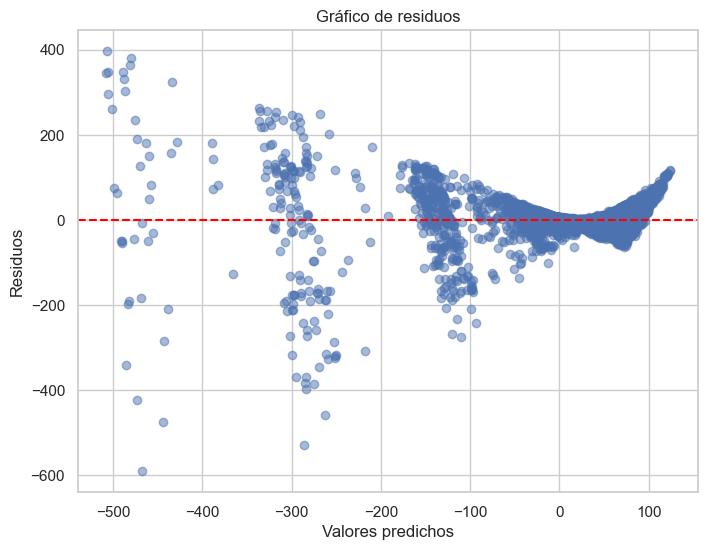

In [14]:
# GRÁFICO DE RESIDUOS
import matplotlib.pyplot as plt

residuos = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Gráfico de residuos")
plt.savefig("output/ej2_residuos.png", dpi=150)
plt.show()

In [15]:
coeficientes = pd.Series(model.coef_, index=X.columns)
coeficientes.sort_values(key=abs, ascending=False).head(10)

PRECIO_TOTAL_SIN_DESCUENTO          36616.279560
PRECIO_TOTAL_CON_DESCUENTO         -33386.870310
DESCUENTO                           -6404.758801
MARGEN_PORCENTAJE                      84.926101
ESTADO_ENTREGA_Shipping canceled        0.828739
PRECIO_PRODUCTO                        -0.821009
ESTADO_PEDIDO_SUSPECTED_FRAUD          -0.674336
NOMBRE_SECCION_Footwear                -0.667668
PAIS_CLIENTE_Puerto Rico               -0.517092
ESTADO_PEDIDO_ON_HOLD                  -0.437802
dtype: float64